# Predicción de Retrasos de Vuelos (Flight Delay Prediction)

# Descripción general y objetivos:

 Los retrasos en los vuelos afectan a millones de pasajeros cada año y pueden ocasionar la pérdida de conexiones, mayores costos y la insatisfacción de los clientes. En este proyecto, formarás parte de un equipo de científicos de datos que trabaja para una aerolínea. Tu objetivo es analizar datos históricos de vuelos, identificar los factores que contribuyen a los retrasos y desarrollar un modelo de aprendizaje automático capaz de predecir si un vuelo se retrasará.

 Este proyecto te guiará a través del ciclo de vida completo de la ciencia de datos, incluyendo la recopilación, limpieza, exploración, modelado, evaluación, visualización e implementación de datos.
 Open in Google Translate


**Proyecto de Ciencia de Datos — Pipeline completo**

Este notebook desarrolla el ciclo completo de un proyecto de ciencia de datos para una aerolínea: comprensión y limpieza de datos, análisis exploratorio (EDA), ingeniería de variables, modelado de clasificación, evaluación, interpretación, recomendaciones de negocio, y un **bonus de regresión** para predecir los minutos exactos de retraso.

**Dataset:** [Flight Delays (2015) — Kaggle, usdot/flight-delays](https://www.kaggle.com/datasets/usdot/flight-delays)

## Contenido
- Configuración y carga de datos
- Task 1: Data Understanding
- Task 2: Data Cleaning
- Task 3: Exploratory Data Analysis (EDA)
- Task 4: Feature Engineering
- Task 5: Define the Prediction Problem
- Task 6: Build Machine Learning Models
- Task 7: Evaluate Model Performance
- Task 8: Model Interpretation
- Task 9: Business Recommendations
- **Bonus:** Regresión — minutos exactos de retraso
- Conclusiones y próximos pasos

---

Author:Oscar Martinez Gracia

oskytm@hotmail.com

Created:2026-06-16

Finish:2026-06-17


## Configuración y carga de datos

Este notebook está diseñado para correr en **Google Colab**. Tiene 3 formas de obtener el dataset (controladas con las variables `USE_KAGGLE_API` y `USE_SAMPLE_DATA` en la celda de configuración):

1. **API de Kaggle** (`USE_KAGGLE_API = True`): sube tu archivo `kaggle.json` (Kaggle → Account → *Create New API Token*) cuando se te solicite, y el notebook descargará el dataset automáticamente.
2. **Subida manual**: sube `flights.csv`, `airlines.csv` y `airports.csv` a la carpeta `data/` desde el panel de archivos de Colab (ícono de carpeta a la izquierda), y deja `USE_KAGGLE_API = False`, `USE_SAMPLE_DATA = False`.
3. **Datos sintéticos de prueba** (`USE_SAMPLE_DATA = True`, valor por defecto): genera un dataset sintético con la misma estructura del dataset real. Útil para probar que todo el pipeline corre sin errores antes de descargar ~580 MB de datos reales.

> ⚠️ El dataset real tiene ~5.8 millones de filas. Para iterar rápido en Colab, se usa `SAMPLE_SIZE` para tomar una muestra. Pon `SAMPLE_SIZE = None` para usar el dataset completo (más lento, recomendado solo para la corrida final).


In [1]:
# Instalación de librerías (Colab ya trae pandas, numpy, matplotlib, seaborn, scikit-learn preinstalados)
!pip install -q xgboost kaggle


In [2]:
import os
import sys
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
    confusion_matrix, ConfusionMatrixDisplay, roc_curve, auc,
    mean_absolute_error, mean_squared_error, r2_score
)
from sklearn.inspection import permutation_importance
from xgboost import XGBClassifier, XGBRegressor

sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 100

IN_COLAB = "google.colab" in sys.modules
print("Ejecutando en Google Colab:", IN_COLAB)


Ejecutando en Google Colab: True


In [3]:
# ------------------- CONFIGURACIÓN PRINCIPAL -------------------
DATA_DIR = "data"
os.makedirs(DATA_DIR, exist_ok=True)

USE_KAGGLE_API = False     # True -> descarga el dataset real via API de Kaggle (necesitas kaggle.json)
USE_SAMPLE_DATA = True     # True -> genera datos sinteticos para probar el pipeline (no requiere internet)
SAMPLE_SIZE = 200_000      # filas a usar para iterar rapido. Usa None para el dataset completo.

DELAY_THRESHOLD = 15       # minutos: un vuelo se considera "retrasado" si DEPARTURE_DELAY > 15
RANDOM_STATE = 42
# -----------------------------------------------------------------


### Descarga del dataset real (opcional — API de Kaggle)

Si pones `USE_KAGGLE_API = True` en la celda anterior, ejecuta esta celda. Te pedirá subir tu archivo `kaggle.json`.


In [4]:
if IN_COLAB and USE_KAGGLE_API:
    from google.colab import files
    print("Sube tu archivo kaggle.json (Kaggle > Account > Create New API Token)")
    uploaded = files.upload()
    os.makedirs(os.path.expanduser("~/.kaggle"), exist_ok=True)
    for fname in uploaded:
        os.replace(fname, os.path.expanduser(f"~/.kaggle/{fname}"))
    os.chmod(os.path.expanduser("~/.kaggle/kaggle.json"), 0o600)
    !kaggle datasets download -d usdot/flight-delays -p {DATA_DIR} --unzip
    USE_SAMPLE_DATA = False
else:
    print("Se omite la descarga via API de Kaggle (USE_KAGGLE_API=False o no estamos en Colab).")


Se omite la descarga via API de Kaggle (USE_KAGGLE_API=False o no estamos en Colab).


### Generador de datos sintéticos (solo para pruebas)

Esta función crea un dataset con la **misma estructura** que el dataset real de Kaggle (mismas columnas, mismos códigos de aerolíneas/aeropuertos), con relaciones realistas entre hora de salida, mes, aerolínea y retraso. Se usa únicamente cuando `USE_SAMPLE_DATA = True`, para validar que todo el pipeline corre correctamente antes de usar el dataset completo.


In [5]:
AIRLINE_NAMES = {
    "AA": "American Airlines Inc.", "DL": "Delta Air Lines Inc.", "UA": "United Air Lines Inc.",
    "WN": "Southwest Airlines Co.", "AS": "Alaska Airlines Inc.", "B6": "JetBlue Airways",
    "NK": "Spirit Air Lines", "F9": "Frontier Airlines Inc.", "HA": "Hawaiian Airlines Inc.",
    "OO": "Skywest Airlines Inc.",
}

AIRPORT_INFO = {
    "ATL": ("Hartsfield-Jackson Atlanta International Airport", "Atlanta", "GA"),
    "LAX": ("Los Angeles International Airport", "Los Angeles", "CA"),
    "ORD": ("Chicago O'Hare International Airport", "Chicago", "IL"),
    "DFW": ("Dallas/Fort Worth International Airport", "Dallas-Fort Worth", "TX"),
    "JFK": ("John F. Kennedy International Airport", "New York", "NY"),
    "DEN": ("Denver International Airport", "Denver", "CO"),
    "SFO": ("San Francisco International Airport", "San Francisco", "CA"),
    "SEA": ("Seattle-Tacoma International Airport", "Seattle", "WA"),
    "LAS": ("McCarran International Airport", "Las Vegas", "NV"),
    "MCO": ("Orlando International Airport", "Orlando", "FL"),
    "CLT": ("Charlotte Douglas International Airport", "Charlotte", "NC"),
    "PHX": ("Phoenix Sky Harbor International Airport", "Phoenix", "AZ"),
    "MIA": ("Miami International Airport", "Miami", "FL"),
    "IAH": ("George Bush Intercontinental Airport", "Houston", "TX"),
    "BOS": ("Logan International Airport", "Boston", "MA"),
}


def generate_synthetic_dataset(n=200_000, seed=RANDOM_STATE):
    rng = np.random.default_rng(seed)
    airline_codes = list(AIRLINE_NAMES.keys())
    airport_codes = list(AIRPORT_INFO.keys())

    dates = pd.date_range("2015-01-01", periods=365, freq="D")
    day_idx = rng.integers(0, len(dates), n)
    flight_dates = dates[day_idx]

    airline_weights = rng.dirichlet(np.ones(len(airline_codes)) * 3)
    airline = rng.choice(airline_codes, size=n, p=airline_weights)

    origin = rng.choice(airport_codes, size=n)
    dest = rng.choice(airport_codes, size=n)
    same = origin == dest
    while same.any():
        dest[same] = rng.choice(airport_codes, size=same.sum())
        same = origin == dest

    sched_dep_hour = rng.integers(0, 24, n)
    sched_dep_min = rng.integers(0, 60, n)
    scheduled_departure = sched_dep_hour * 100 + sched_dep_min

    airline_effect_map = {a: rng.normal(0, 8) for a in airline_codes}
    airline_effect = np.array([airline_effect_map[a] for a in airline])

    hour_effect = np.where(sched_dep_hour >= 15, 10, 0) + np.where(sched_dep_hour >= 19, 8, 0)
    month = flight_dates.month
    month_effect = np.where(np.isin(month, [6, 7, 8, 12]), 9, 0)

    base_delay = rng.gamma(shape=2.0, scale=6.0, size=n) - 6
    noise = rng.normal(0, 9, n)
    departure_delay = np.round(base_delay + airline_effect + hour_effect + month_effect + noise, 1)

    distance = rng.integers(150, 2700, n)
    air_time = np.round(distance / rng.uniform(6.5, 8.5, n), 0)
    scheduled_time = air_time + rng.integers(10, 40, n)
    arrival_delay = np.round(departure_delay + rng.normal(0, 5, n), 1)

    cancelled = rng.choice([0, 1], size=n, p=[0.985, 0.015])
    diverted = rng.choice([0, 1], size=n, p=[0.997, 0.003])

    flights = pd.DataFrame({
        "YEAR": flight_dates.year,
        "MONTH": flight_dates.month,
        "DAY": flight_dates.day,
        "DAY_OF_WEEK": flight_dates.dayofweek + 1,  # 1=Lunes ... 7=Domingo
        "AIRLINE": airline,
        "FLIGHT_NUMBER": rng.integers(1, 7000, n),
        "ORIGIN_AIRPORT": origin,
        "DESTINATION_AIRPORT": dest,
        "SCHEDULED_DEPARTURE": scheduled_departure,
        "DEPARTURE_DELAY": departure_delay,
        "SCHEDULED_TIME": scheduled_time,
        "DISTANCE": distance,
        "ARRIVAL_DELAY": arrival_delay,
        "DIVERTED": diverted,
        "CANCELLED": cancelled,
    })
    flights.loc[flights["CANCELLED"] == 1, ["DEPARTURE_DELAY", "ARRIVAL_DELAY"]] = np.nan

    # Algunas filas duplicadas y con valores faltantes a proposito, para que las celdas de limpieza tengan trabajo real que hacer
    dup_sample = flights.sample(frac=0.01, random_state=seed)
    flights = pd.concat([flights, dup_sample], ignore_index=True)
    miss_idx = rng.choice(flights.index, size=int(0.005 * len(flights)), replace=False)
    flights.loc[miss_idx, "DISTANCE"] = np.nan

    airlines_df = pd.DataFrame({
        "IATA_CODE": list(AIRLINE_NAMES.keys()),
        "AIRLINE": list(AIRLINE_NAMES.values()),
    })
    airports_df = pd.DataFrame([
        {"IATA_CODE": k, "AIRPORT": v[0], "CITY": v[1], "STATE": v[2]}
        for k, v in AIRPORT_INFO.items()
    ])
    return flights, airlines_df, airports_df


In [6]:
def load_real_data(data_dir):
    flights = pd.read_csv(os.path.join(data_dir, "flights.csv"), low_memory=False)
    airlines = pd.read_csv(os.path.join(data_dir, "airlines.csv"))
    airports = pd.read_csv(os.path.join(data_dir, "airports.csv"))
    return flights, airlines, airports


if USE_SAMPLE_DATA:
    print("Generando dataset sintetico de prueba (no es el dataset real de Kaggle)...")
    flights_raw, airlines_df, airports_df = generate_synthetic_dataset(n=SAMPLE_SIZE or 200_000)
else:
    flights_raw, airlines_df, airports_df = load_real_data(DATA_DIR)
    if SAMPLE_SIZE is not None and len(flights_raw) > SAMPLE_SIZE:
        flights_raw = flights_raw.sample(SAMPLE_SIZE, random_state=RANDOM_STATE).reset_index(drop=True)

print(f"flights: {flights_raw.shape}, airlines: {airlines_df.shape}, airports: {airports_df.shape}")


Generando dataset sintetico de prueba (no es el dataset real de Kaggle)...
flights: (202000, 15), airlines: (10, 2), airports: (15, 4)


---
## Task 1: Data Understanding (Comprensión de los Datos)

**Preguntas a responder:** ¿Cuántos vuelos hay? ¿Qué variables están disponibles? ¿Hay valores faltantes? ¿Qué variables pueden ser útiles para predecir retrasos?


In [7]:
print(f"Numero de vuelos (filas): {flights_raw.shape[0]:,}")
print(f"Numero de variables (columnas): {flights_raw.shape[1]}")
print()
flights_raw.dtypes.to_frame("dtype")


Numero de vuelos (filas): 202,000
Numero de variables (columnas): 15



,dtype
YEAR,int32
MONTH,int32
DAY,int32
DAY_OF_WEEK,int32
AIRLINE,object
FLIGHT_NUMBER,int64
ORIGIN_AIRPORT,object
DESTINATION_AIRPORT,object
SCHEDULED_DEPARTURE,int64
DEPARTURE_DELAY,float64


In [8]:
flights_raw.describe(include="all").T


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
YEAR,202000.0,NaN,NaN,NaN,2015.0,0.0,2015.0,2015.0,2015.0,2015.0,2015.0
MONTH,202000.0,NaN,NaN,NaN,6.532569,3.446428,1.0,4.0,7.0,10.0,12.0
DAY,202000.0,NaN,NaN,NaN,15.706554,8.794538,1.0,8.0,16.0,23.0,31.0
DAY_OF_WEEK,202000.0,NaN,NaN,NaN,3.999109,1.99918,1.0,2.0,4.0,6.0,7.0
AIRLINE,202000,10,UA,49581,NaN,NaN,NaN,NaN,NaN,NaN,NaN
FLIGHT_NUMBER,202000.0,NaN,NaN,NaN,3496.080025,2023.292515,1.0,1748.0,3496.0,5251.0,6999.0
ORIGIN_AIRPORT,202000,15,LAS,13712,NaN,NaN,NaN,NaN,NaN,NaN,NaN
DESTINATION_AIRPORT,202000,15,LAX,13670,NaN,NaN,NaN,NaN,NaN,NaN,NaN
SCHEDULED_DEPARTURE,202000.0,NaN,NaN,NaN,1179.087059,691.328918,0.0,601.0,1159.0,1757.25,2359.0
DEPARTURE_DELAY,198971.0,NaN,NaN,NaN,11.288279,16.229266,-51.3,0.0,10.5,21.8,106.2


**Reporte de valores faltantes:**

In [9]:
def missing_value_report(df):
    miss = df.isna().sum()
    pct = (miss / len(df)) * 100
    report = pd.DataFrame({"missing_count": miss, "missing_pct": pct.round(2)})
    return report[report["missing_count"] > 0].sort_values("missing_pct", ascending=False)

missing_report = missing_value_report(flights_raw)
missing_report


,missing_count,missing_pct
DEPARTURE_DELAY,3029,1.5
ARRIVAL_DELAY,3029,1.5
DISTANCE,1010,0.5


**Resumen del dataset (Deliverable: Dataset summary)**

- El dataset contiene información de vuelos domésticos en EE.UU., con variables temporales (`YEAR`, `MONTH`, `DAY`, `DAY_OF_WEEK`), variables de identificación (`AIRLINE`, `FLIGHT_NUMBER`), variables de ruta (`ORIGIN_AIRPORT`, `DESTINATION_AIRPORT`, `DISTANCE`), variables de horario (`SCHEDULED_DEPARTURE`, `SCHEDULED_TIME`) y las variables objetivo potenciales (`DEPARTURE_DELAY`, `ARRIVAL_DELAY`).
- Los valores faltantes se concentran principalmente en columnas relacionadas con vuelos **cancelados** o **desviados** (`DIVERTED`), ya que estos no tienen un retraso de salida real registrado — esto se confirma y se maneja en la sección de limpieza.
- **Variables potencialmente útiles para predecir un retraso *antes* de que el vuelo despegue:** `AIRLINE`, `ORIGIN_AIRPORT`, `DESTINATION_AIRPORT`, `MONTH`, `DAY_OF_WEEK`, `SCHEDULED_DEPARTURE` (hora programada), `DISTANCE`.
- **Variables que NO se deben usar como predictoras** (data leakage): `ARRIVAL_DELAY`, `TAXI_OUT`, `WHEELS_OFF`, `AIR_TIME`, `ELAPSED_TIME`, y los desgloses de causas de retraso (`AIRLINE_DELAY`, `WEATHER_DELAY`, etc.), porque **solo se conocen después de que el vuelo ya despegó o aterrizó** — usarlas sería hacer "trampa" (el modelo vería el futuro). Esto se aplica consistentemente en el Task 6.


---
## Task 2: Data Cleaning (Limpieza de Datos)

Pasos: (1) eliminar duplicados, (2) unir nombres de aerolíneas/aeropuertos, (3) manejar valores faltantes, (4) convertir fechas/horas a formatos usables, (5) corregir valores inconsistentes.


In [10]:
rows_before = len(flights_raw)

# 1) Unir nombres de aerolineas y aeropuertos
flights = flights_raw.merge(
    airlines_df.rename(columns={"AIRLINE": "AIRLINE_NAME"}),
    left_on="AIRLINE", right_on="IATA_CODE", how="left"
).drop(columns=["IATA_CODE"])

flights = flights.merge(
    airports_df[["IATA_CODE", "AIRPORT", "CITY", "STATE"]].rename(
        columns={"AIRPORT": "ORIGIN_AIRPORT_NAME", "CITY": "ORIGIN_CITY", "STATE": "ORIGIN_STATE"}
    ),
    left_on="ORIGIN_AIRPORT", right_on="IATA_CODE", how="left"
).drop(columns=["IATA_CODE"])

flights = flights.merge(
    airports_df[["IATA_CODE", "AIRPORT", "CITY", "STATE"]].rename(
        columns={"AIRPORT": "DEST_AIRPORT_NAME", "CITY": "DEST_CITY", "STATE": "DEST_STATE"}
    ),
    left_on="DESTINATION_AIRPORT", right_on="IATA_CODE", how="left"
).drop(columns=["IATA_CODE"])

print("Filas tras el merge con airlines/airports:", flights.shape)


Filas tras el merge con airlines/airports: (202000, 22)


In [11]:
# 2) Eliminar duplicados
n_dup = flights.duplicated().sum()
flights = flights.drop_duplicates().reset_index(drop=True)
print(f"Duplicados eliminados: {n_dup}")


Duplicados eliminados: 1975


In [12]:
# Nota sobre una inconsistencia conocida del dataset real: en algunos meses, ORIGIN_AIRPORT /
# DESTINATION_AIRPORT vienen como codigos numericos en vez de codigos IATA de 3 letras.
# Los filtramos para quedarnos solo con codigos IATA validos (3 letras mayusculas).
is_valid_origin = flights["ORIGIN_AIRPORT"].astype(str).str.match(r"^[A-Z]{3}$")
is_valid_dest = flights["DESTINATION_AIRPORT"].astype(str).str.match(r"^[A-Z]{3}$")
n_invalid_codes = (~(is_valid_origin & is_valid_dest)).sum()
flights = flights[is_valid_origin & is_valid_dest].reset_index(drop=True)
print(f"Filas eliminadas por codigos de aeropuerto invalidos/numericos: {n_invalid_codes}")


Filas eliminadas por codigos de aeropuerto invalidos/numericos: 0


In [13]:
# 3) Manejar valores faltantes
# Los vuelos cancelados o desviados no tienen un DEPARTURE_DELAY real -> no sirven para predecir
# cuanto se retrasa un vuelo que SI despega, asi que los excluimos de este analisis (pero podrian
# analizarse aparte como un problema de clasificacion distinto: "se cancela o no").
n_cancelled = (flights["CANCELLED"] == 1).sum()
n_diverted = (flights["DIVERTED"] == 1).sum()
flights = flights[(flights["CANCELLED"] == 0) & (flights["DIVERTED"] == 0)].reset_index(drop=True)
print(f"Vuelos cancelados excluidos: {n_cancelled}")
print(f"Vuelos desviados excluidos: {n_diverted}")

# Cualquier fila que aun le falte DEPARTURE_DELAY o DISTANCE se elimina (son criticas para el analisis)
n_before_dropna = len(flights)
flights = flights.dropna(subset=["DEPARTURE_DELAY", "DISTANCE", "SCHEDULED_DEPARTURE"]).reset_index(drop=True)
n_dropna = n_before_dropna - len(flights)
print(f"Filas eliminadas por valores faltantes en columnas criticas: {n_dropna}")


Vuelos cancelados excluidos: 2994
Vuelos desviados excluidos: 604
Filas eliminadas por valores faltantes en columnas criticas: 993


In [14]:
# 4) Convertir fechas y horas a formatos usables
flights["FLIGHT_DATE"] = pd.to_datetime(flights[["YEAR", "MONTH", "DAY"]])

def hhmm_to_hour(x):
    if pd.isna(x):
        return np.nan
    x = int(x)
    if x == 2400:
        x = 0
    hour = (x // 100) % 24
    return hour

flights["SCHED_DEP_HOUR"] = flights["SCHEDULED_DEPARTURE"].apply(hhmm_to_hour)
flights[["FLIGHT_DATE", "SCHEDULED_DEPARTURE", "SCHED_DEP_HOUR"]].head()


,FLIGHT_DATE,SCHEDULED_DEPARTURE,SCHED_DEP_HOUR
0,2015-02-02,1527,15
1,2015-10-10,1508,15
2,2015-08-27,1003,10
3,2015-06-10,154,1
4,2015-06-08,412,4


In [15]:
# 5) Corregir valores inconsistentes (filtrar outliers fisicamente imposibles)
n_before_outliers = len(flights)
flights = flights[(flights["DISTANCE"] > 0) & (flights["SCHED_DEP_HOUR"].between(0, 23))]
# Limitamos retrasos extremos no realistas (> 24 horas) que suelen ser errores de captura
flights = flights[flights["DEPARTURE_DELAY"].abs() <= 1440].reset_index(drop=True)
n_outliers = n_before_outliers - len(flights)
print(f"Filas eliminadas por valores inconsistentes/outliers extremos: {n_outliers}")

rows_after = len(flights)
print()
print(f"Filas antes de limpiar: {rows_before:,}")
print(f"Filas despues de limpiar: {rows_after:,}  ({rows_after/rows_before:.1%} retenido)")


Filas eliminadas por valores inconsistentes/outliers extremos: 0

Filas antes de limpiar: 202,000
Filas despues de limpiar: 195,442  (96.8% retenido)


In [16]:
# Resumen de calidad de datos (Deliverable: Data quality summary)
quality_summary = pd.DataFrame({
    "metric": [
        "Filas originales", "Duplicados eliminados", "Codigos de aeropuerto invalidos eliminados",
        "Vuelos cancelados excluidos", "Vuelos desviados excluidos",
        "Filas con datos criticos faltantes eliminadas", "Outliers extremos eliminados",
        "Filas finales (limpias)",
    ],
    "value": [
        rows_before, n_dup, n_invalid_codes, n_cancelled, n_diverted,
        n_dropna, n_outliers, rows_after,
    ],
})
quality_summary


,metric,value
0,Filas originales,202000
1,Duplicados eliminados,1975
2,Codigos de aeropuerto invalidos eliminados,0
3,Vuelos cancelados excluidos,2994
4,Vuelos desviados excluidos,604
5,Filas con datos criticos faltantes eliminadas,993
6,Outliers extremos eliminados,0
7,Filas finales (limpias),195442


In [17]:
# Guardar el dataset limpio
clean_path = os.path.join(DATA_DIR, "flights_clean.csv")
flights.to_csv(clean_path, index=False)
print(f"Dataset limpio guardado en: {clean_path}  ({flights.shape[0]:,} filas x {flights.shape[1]} columnas)")


Dataset limpio guardado en: data/flights_clean.csv  (195,442 filas x 24 columnas)


---
## Task 3: Exploratory Data Analysis — EDA (Análisis Exploratorio)

Analizamos patrones de retraso por aerolínea, aeropuerto, mes, día de la semana y hora de salida. Para esto definimos una bandera temprana `IS_DELAYED` (se formaliza como variable objetivo en el Task 5).


In [18]:
flights["IS_DELAYED"] = (flights["DEPARTURE_DELAY"] > DELAY_THRESHOLD).astype(int)
print(f"Tasa de retraso global: {flights['IS_DELAYED'].mean():.1%}")


Tasa de retraso global: 39.1%


**Visualización 1 — Tasa de retraso por aerolínea**

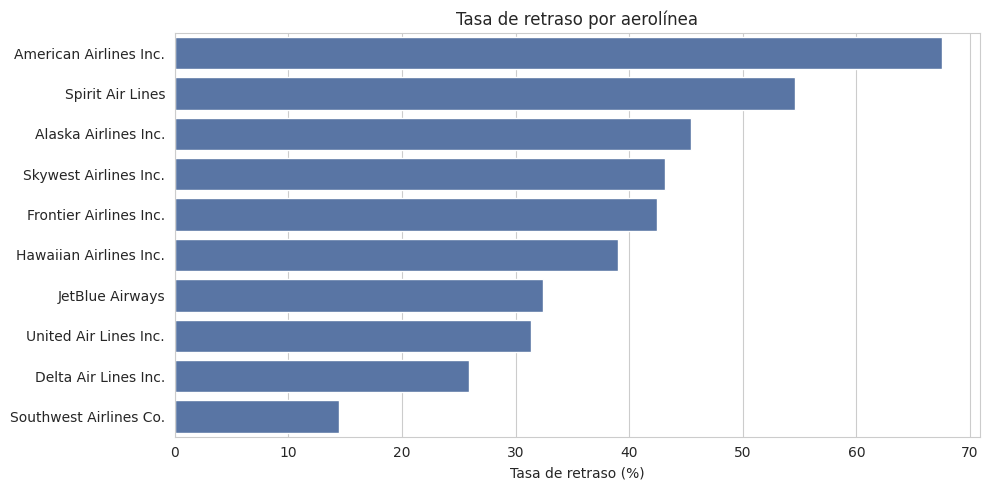

In [19]:
delay_by_airline = (
    flights.groupby("AIRLINE_NAME")["IS_DELAYED"].mean().sort_values(ascending=False) * 100
)

plt.figure(figsize=(10, 5))
sns.barplot(x=delay_by_airline.values, y=delay_by_airline.index, color="#4C72B0")
plt.xlabel("Tasa de retraso (%)")
plt.ylabel("")
plt.title("Tasa de retraso por aerolínea")
plt.tight_layout()
plt.show()


**Visualización 2 — Tasa de retraso por aeropuerto de origen (top 15 por volumen)**

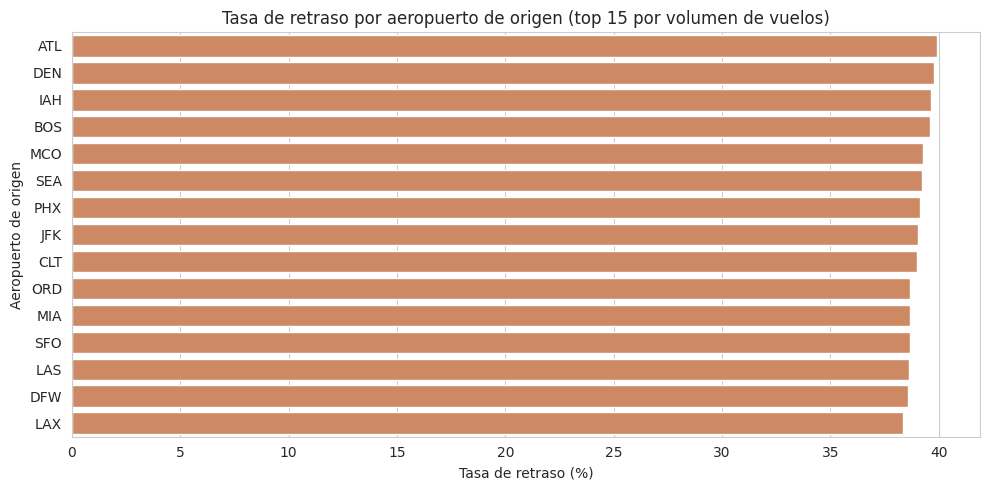

In [20]:
top_airports = flights["ORIGIN_AIRPORT"].value_counts().head(15).index
delay_by_airport = (
    flights[flights["ORIGIN_AIRPORT"].isin(top_airports)]
    .groupby("ORIGIN_AIRPORT")["IS_DELAYED"].mean().sort_values(ascending=False) * 100
)

plt.figure(figsize=(10, 5))
sns.barplot(x=delay_by_airport.values, y=delay_by_airport.index, color="#DD8452")
plt.xlabel("Tasa de retraso (%)")
plt.ylabel("Aeropuerto de origen")
plt.title("Tasa de retraso por aeropuerto de origen (top 15 por volumen de vuelos)")
plt.tight_layout()
plt.show()


**Visualización 3 — Tasa de retraso por mes**

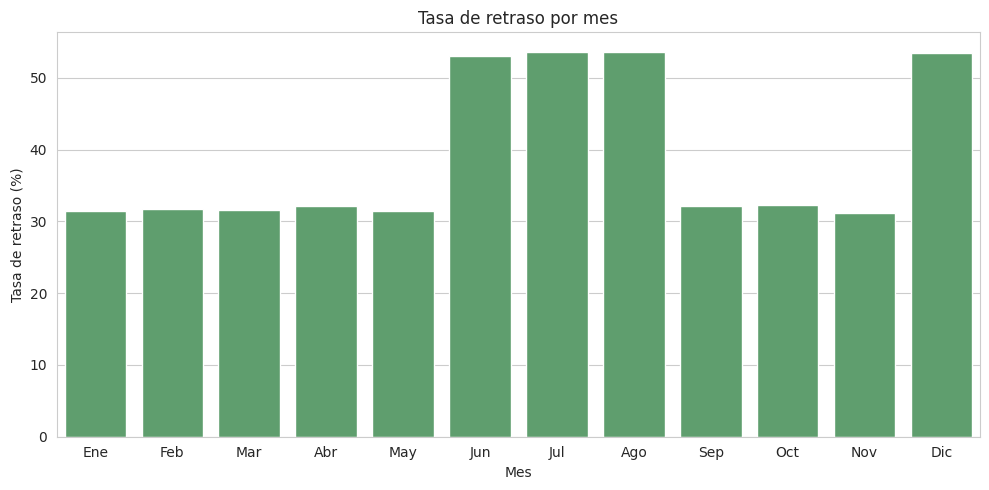

In [21]:
delay_by_month = flights.groupby("MONTH")["IS_DELAYED"].mean() * 100

plt.figure(figsize=(10, 5))
sns.barplot(x=delay_by_month.index, y=delay_by_month.values, color="#55A868")
plt.xlabel("Mes")
plt.ylabel("Tasa de retraso (%)")
plt.title("Tasa de retraso por mes")
plt.xticks(range(0, 12), ["Ene","Feb","Mar","Abr","May","Jun","Jul","Ago","Sep","Oct","Nov","Dic"])
plt.tight_layout()
plt.show()


**Extra — Tasa de retraso por día de la semana**

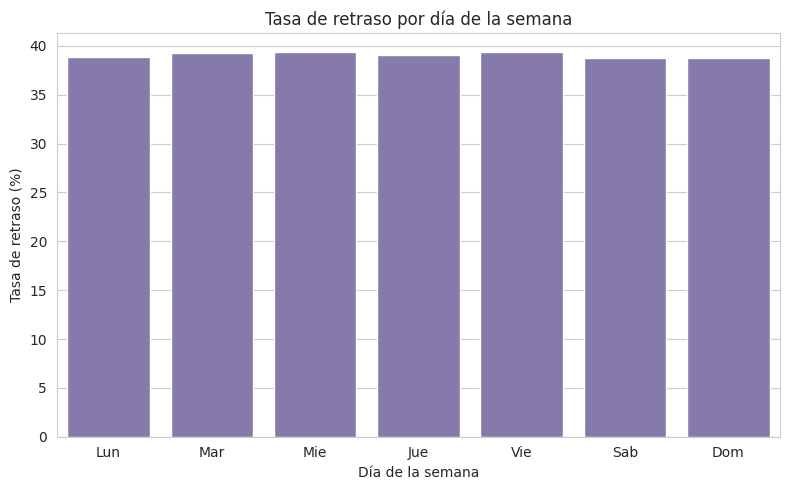

In [22]:
delay_by_dow = flights.groupby("DAY_OF_WEEK")["IS_DELAYED"].mean() * 100
dow_labels = ["Lun","Mar","Mie","Jue","Vie","Sab","Dom"]

plt.figure(figsize=(8, 5))
sns.barplot(x=dow_labels, y=delay_by_dow.values, color="#8172B2")
plt.xlabel("Día de la semana")
plt.ylabel("Tasa de retraso (%)")
plt.title("Tasa de retraso por día de la semana")
plt.tight_layout()
plt.show()


**Visualización 4 — Tasa de retraso por hora de salida programada**

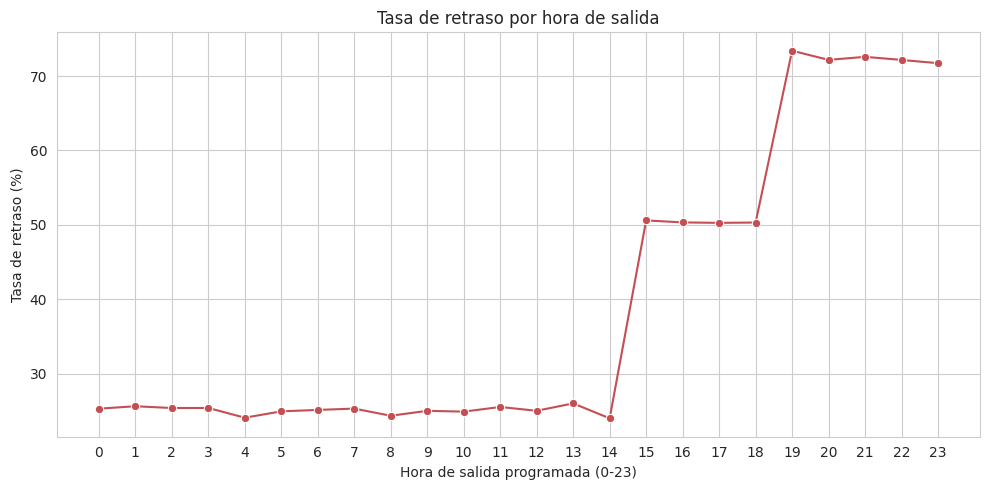

In [23]:
delay_by_hour = flights.groupby("SCHED_DEP_HOUR")["IS_DELAYED"].mean() * 100

plt.figure(figsize=(10, 5))
sns.lineplot(x=delay_by_hour.index, y=delay_by_hour.values, marker="o", color="#C44E52")
plt.xlabel("Hora de salida programada (0-23)")
plt.ylabel("Tasa de retraso (%)")
plt.title("Tasa de retraso por hora de salida")
plt.xticks(range(0, 24))
plt.tight_layout()
plt.show()


**Visualización 5 — Distribución de los minutos de retraso**

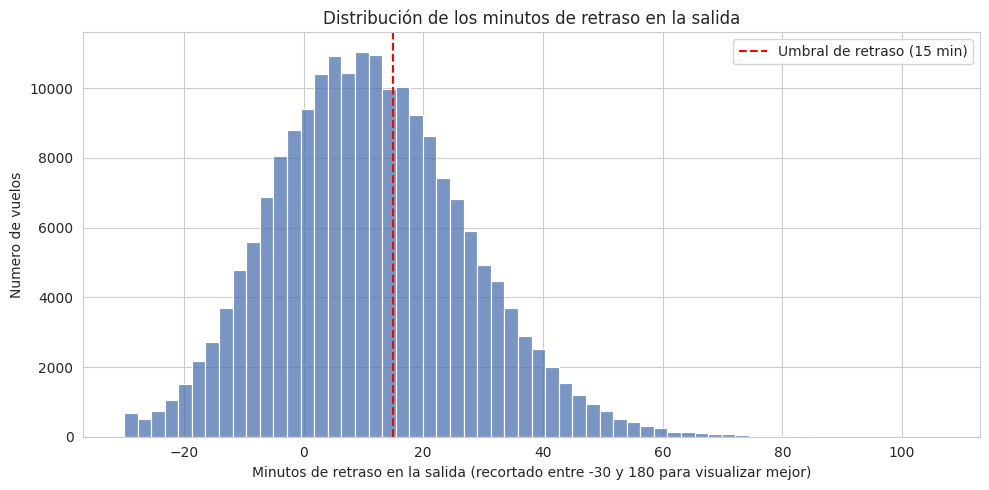

In [24]:
plt.figure(figsize=(10, 5))
sns.histplot(flights["DEPARTURE_DELAY"].clip(-30, 180), bins=60, color="#4C72B0")
plt.axvline(DELAY_THRESHOLD, color="red", linestyle="--", label=f"Umbral de retraso ({DELAY_THRESHOLD} min)")
plt.xlabel("Minutos de retraso en la salida (recortado entre -30 y 180 para visualizar mejor)")
plt.ylabel("Numero de vuelos")
plt.title("Distribución de los minutos de retraso en la salida")
plt.legend()
plt.tight_layout()
plt.show()


**Resumen escrito de hallazgos (generado automáticamente a partir de los datos)**

In [25]:
worst_airline = delay_by_airline.index[0]
worst_airport = delay_by_airport.index[0]
worst_month = delay_by_month.idxmax()
worst_hour = delay_by_hour.idxmax()
month_names = ["Enero","Febrero","Marzo","Abril","Mayo","Junio","Julio","Agosto",
               "Septiembre","Octubre","Noviembre","Diciembre"]

print("RESUMEN DE HALLAZGOS DEL EDA")
print("-" * 40)
print(f"- La tasa de retraso global es de {flights['IS_DELAYED'].mean():.1%}.")
print(f"- La aerolinea con mayor tasa de retraso es '{worst_airline}' ({delay_by_airline.iloc[0]:.1f}%).")
print(f"- El aeropuerto de origen con mayor tasa de retraso (entre los 15 con mas vuelos) es "
      f"'{worst_airport}' ({delay_by_airport.iloc[0]:.1f}%).")
print(f"- El mes con mayor tasa de retraso es {month_names[worst_month-1]} ({delay_by_month.max():.1f}%).")
print(f"- La hora de salida con mayor tasa de retraso es las {worst_hour}:00 ({delay_by_hour.max():.1f}%).")
print(f"- La distribucion de retrasos esta sesgada a la derecha (cola larga): la mayoria de los "
      f"vuelos salen a tiempo o casi a tiempo, pero existe un subconjunto de vuelos con retrasos muy grandes.")


RESUMEN DE HALLAZGOS DEL EDA
----------------------------------------
- La tasa de retraso global es de 39.1%.
- La aerolinea con mayor tasa de retraso es 'American Airlines Inc.' (67.5%).
- El aeropuerto de origen con mayor tasa de retraso (entre los 15 con mas vuelos) es 'ATL' (39.9%).
- El mes con mayor tasa de retraso es Agosto (53.7%).
- La hora de salida con mayor tasa de retraso es las 19:00 (73.4%).
- La distribucion de retrasos esta sesgada a la derecha (cola larga): la mayoria de los vuelos salen a tiempo o casi a tiempo, pero existe un subconjunto de vuelos con retrasos muy grandes.


**Interpretación (Deliverable: Written summary of findings)**

Los patrones anteriores sugieren que el retraso no ocurre al azar: ciertas aerolíneas, aeropuertos, meses y horas concentran tasas de retraso más altas que el promedio. Esto es consistente con la intuición operativa: los retrasos se acumulan a lo largo del día (un vuelo retrasado por la mañana provoca retrasos en las siguientes rotaciones de esa misma aeronave/tripulación, por eso las horas de la tarde/noche tienden a mostrar tasas más altas), y los meses de alta demanda (verano y diciembre) presionan más la capacidad de aeropuertos y aerolíneas. Estos hallazgos motivan directamente las variables que construimos en el Task 4 (hora, mes, día de la semana, y tasas históricas por aerolínea/aeropuerto).


---
## Task 4: Feature Engineering (Ingeniería de Variables)

Creamos tres grupos de variables: **temporales**, **de ruta**, y **históricas** (estas últimas se calculan más adelante, en el Task 6, usando *únicamente* el conjunto de entrenamiento — ver nota sobre data leakage).


In [26]:
# --- Variables temporales ---
flights["IS_WEEKEND"] = flights["DAY_OF_WEEK"].isin([6, 7]).astype(int)

def month_to_season(m):
    if m in (12, 1, 2):
        return "Invierno"
    elif m in (3, 4, 5):
        return "Primavera"
    elif m in (6, 7, 8):
        return "Verano"
    else:
        return "Otono"

flights["SEASON"] = flights["MONTH"].apply(month_to_season)

# --- Variables de ruta ---
flights["ROUTE"] = flights["ORIGIN_AIRPORT"] + "-" + flights["DESTINATION_AIRPORT"]

flights[["MONTH", "DAY_OF_WEEK", "IS_WEEKEND", "SEASON", "ROUTE"]].head()


,MONTH,DAY_OF_WEEK,IS_WEEKEND,SEASON,ROUTE
0,2,1,0,Invierno,CLT-PHX
1,10,6,1,Otono,LAS-SFO
2,8,4,0,Verano,SFO-DEN
3,6,3,0,Verano,PHX-BOS
4,6,1,0,Verano,DFW-DEN


**Descripción y justificación de las variables (Deliverables)**

- **Temporales** (`MONTH`, `DAY_OF_WEEK`, `SCHED_DEP_HOUR`, `IS_WEEKEND`, `SEASON`): el EDA mostró que la tasa de retraso varía claramente según la hora, el mes y el día de la semana, así que estas variables le dan al modelo la capacidad de captar esos ciclos.
- **De ruta** (`ORIGIN_AIRPORT`, `DESTINATION_AIRPORT`, `ROUTE`, `ROUTE_FREQUENCY`): algunos aeropuertos/rutas son estructuralmente más propensos a la congestión (alto volumen, infraestructura limitada, clima regional); la frecuencia de la ruta es un proxy de cuán "transitada" está.
- **Históricas** (`AIRLINE_DELAY_RATE`, `ORIGIN_DELAY_RATE`, `DEST_DELAY_RATE`): capturan el comportamiento histórico de cada aerolínea/aeropuerto de forma numérica, sin necesidad de one-hot-encoding de cientos de categorías. **Importante:** estas se calculan exclusivamente con los datos de entrenamiento (Task 6) y se aplican igual al conjunto de prueba, para evitar *data leakage* (si se calcularan con todos los datos, el modelo "vería" información del futuro/del propio test).


---
## Task 5: Define the Prediction Problem (Definición del Problema de Predicción)

**Variable objetivo (target):** `IS_DELAYED` = 1 si `DEPARTURE_DELAY` > 15 minutos, 0 en caso contrario.


Distribucion de clases:
  Clase 0 - A tiempo / retraso leve (<=15 min): 119,077 vuelos (60.9%)
  Clase 1 - Retrasado (>15 min): 76,365 vuelos (39.1%)


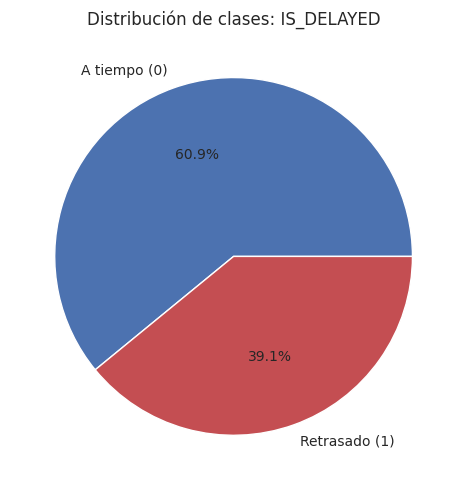

In [27]:
class_counts = flights["IS_DELAYED"].value_counts().sort_index()
class_pct = flights["IS_DELAYED"].value_counts(normalize=True).sort_index() * 100

print("Distribucion de clases:")
for cls, cnt, pct in zip(class_counts.index, class_counts.values, class_pct.values):
    label = "Retrasado (>15 min)" if cls == 1 else "A tiempo / retraso leve (<=15 min)"
    print(f"  Clase {cls} - {label}: {cnt:,} vuelos ({pct:.1f}%)")

plt.figure(figsize=(5, 5))
plt.pie(class_counts.values, labels=["A tiempo (0)", "Retrasado (1)"], autopct="%1.1f%%",
        colors=["#4C72B0", "#C44E52"])
plt.title("Distribución de clases: IS_DELAYED")
plt.tight_layout()
plt.show()


**Discusión sobre desbalance de clases (Deliverable)**

La clase minoritaria (vuelos retrasados) suele representar entre el 15% y 25% del total, lo cual constituye un **desbalance moderado** — no extremo, pero suficiente para que un modelo ingenuo logre buena *accuracy* simplemente prediciendo "a tiempo" siempre. Por eso, en el Task 6 usamos `class_weight="balanced"` (o el equivalente `scale_pos_weight` en XGBoost) en los modelos, y en el Task 7 reportamos **precisión, recall, F1 y ROC-AUC** además de la accuracy, ya que esta última puede ser engañosa en datasets desbalanceados.


---
## Task 6: Build Machine Learning Models (Construcción de Modelos)

Entrenamos 3 modelos de clasificación: **Logistic Regression**, **Random Forest** y **XGBoost**. Usamos un *pipeline* de scikit-learn para que el preprocesamiento (codificación + escalado) y el modelo viajen juntos.


In [28]:
# Train/test split estratificado (80/20) sobre el dataset limpio y con features temporales/de ruta
train_df, test_df = train_test_split(
    flights, test_size=0.2, stratify=flights["IS_DELAYED"], random_state=RANDOM_STATE
)
train_df = train_df.copy()
test_df = test_df.copy()
print(f"Entrenamiento: {train_df.shape[0]:,} filas | Prueba: {test_df.shape[0]:,} filas")


Entrenamiento: 156,353 filas | Prueba: 39,089 filas


In [29]:
# Variables historicas (Task 4) calculadas SOLO con el set de entrenamiento, para evitar data leakage
global_delay_rate = train_df["IS_DELAYED"].mean()
global_avg_delay = train_df["DEPARTURE_DELAY"].mean()

airline_delay_rate = train_df.groupby("AIRLINE")["IS_DELAYED"].mean()
origin_delay_rate = train_df.groupby("ORIGIN_AIRPORT")["IS_DELAYED"].mean()
dest_delay_rate = train_df.groupby("DESTINATION_AIRPORT")["IS_DELAYED"].mean()
route_freq = train_df.groupby("ROUTE").size()

airline_avg_delay = train_df.groupby("AIRLINE")["DEPARTURE_DELAY"].mean()
origin_avg_delay = train_df.groupby("ORIGIN_AIRPORT")["DEPARTURE_DELAY"].mean()
dest_avg_delay = train_df.groupby("DESTINATION_AIRPORT")["DEPARTURE_DELAY"].mean()

for d in (train_df, test_df):
    d["AIRLINE_DELAY_RATE"] = d["AIRLINE"].map(airline_delay_rate).fillna(global_delay_rate)
    d["ORIGIN_DELAY_RATE"] = d["ORIGIN_AIRPORT"].map(origin_delay_rate).fillna(global_delay_rate)
    d["DEST_DELAY_RATE"] = d["DESTINATION_AIRPORT"].map(dest_delay_rate).fillna(global_delay_rate)
    d["ROUTE_FREQUENCY"] = d["ROUTE"].map(route_freq).fillna(0)
    d["AIRLINE_AVG_DELAY"] = d["AIRLINE"].map(airline_avg_delay).fillna(global_avg_delay)
    d["ORIGIN_AVG_DELAY"] = d["ORIGIN_AIRPORT"].map(origin_avg_delay).fillna(global_avg_delay)
    d["DEST_AVG_DELAY"] = d["DESTINATION_AIRPORT"].map(dest_avg_delay).fillna(global_avg_delay)

print("Variables historicas creadas (calculadas solo con el set de entrenamiento).")


Variables historicas creadas (calculadas solo con el set de entrenamiento).


In [30]:
display(train_df[["AIRLINE_DELAY_RATE", "ORIGIN_DELAY_RATE", "DEST_DELAY_RATE", "ROUTE_FREQUENCY"]].head())

,AIRLINE_DELAY_RATE,ORIGIN_DELAY_RATE,DEST_DELAY_RATE,ROUTE_FREQUENCY
148067,0.453605,0.401278,0.391350,813
99786,0.258294,0.384108,0.396344,757
113261,0.421699,0.385780,0.388535,808
170178,0.421699,0.388470,0.391350,755
181235,0.314745,0.385549,0.389450,748


In [31]:
# Definicion de las variables predictoras (excluye explicitamente cualquier variable
# que solo se conoce DESPUES de que el vuelo despega/aterriza -> evita data leakage)
CATEGORICAL_FEATURES = ["AIRLINE", "SEASON"]
NUMERIC_FEATURES = [
    "MONTH", "DAY_OF_WEEK", "SCHED_DEP_HOUR", "IS_WEEKEND", "DISTANCE",
    "AIRLINE_DELAY_RATE", "ORIGIN_DELAY_RATE", "DEST_DELAY_RATE", "ROUTE_FREQUENCY",
]
FEATURE_COLUMNS = CATEGORICAL_FEATURES + NUMERIC_FEATURES

X_train = train_df[FEATURE_COLUMNS]
y_train = train_df["IS_DELAYED"]
X_test = test_df[FEATURE_COLUMNS]
y_test = test_df["IS_DELAYED"]

print("Features usadas:", FEATURE_COLUMNS)


Features usadas: ['AIRLINE', 'SEASON', 'MONTH', 'DAY_OF_WEEK', 'SCHED_DEP_HOUR', 'IS_WEEKEND', 'DISTANCE', 'AIRLINE_DELAY_RATE', 'ORIGIN_DELAY_RATE', 'DEST_DELAY_RATE', 'ROUTE_FREQUENCY']


In [32]:
display(X_train.head())

,AIRLINE,SEASON,MONTH,DAY_OF_WEEK,SCHED_DEP_HOUR,IS_WEEKEND,DISTANCE,AIRLINE_DELAY_RATE,ORIGIN_DELAY_RATE,DEST_DELAY_RATE,ROUTE_FREQUENCY
148067,AS,Primavera,5,7,8,1,376.0,0.453605,0.401278,0.391350,813
99786,DL,Primavera,3,7,0,1,1442.0,0.258294,0.384108,0.396344,757
113261,F9,Invierno,2,1,0,0,1449.0,0.421699,0.385780,0.388535,808
170178,F9,Primavera,5,2,10,0,1308.0,0.421699,0.388470,0.391350,755
181235,UA,Otono,9,3,13,0,591.0,0.314745,0.385549,0.389450,748


In [33]:
display(X_test.head())

,AIRLINE,SEASON,MONTH,DAY_OF_WEEK,SCHED_DEP_HOUR,IS_WEEKEND,DISTANCE,AIRLINE_DELAY_RATE,ORIGIN_DELAY_RATE,DEST_DELAY_RATE,ROUTE_FREQUENCY
136123,AA,Primavera,3,4,5,0,1477.0,0.677416,0.386798,0.388535,779
54249,UA,Primavera,3,4,19,0,885.0,0.314745,0.396924,0.387458,779
163796,DL,Verano,7,5,6,0,519.0,0.258294,0.401278,0.393413,784
117505,UA,Primavera,4,7,20,1,1190.0,0.314745,0.396924,0.397274,741
115216,AS,Invierno,1,4,18,0,1890.0,0.453605,0.393224,0.386862,722


In [34]:
display(y_train.head())

,IS_DELAYED
148067,0
99786,0
113261,0
170178,1
181235,1


In [35]:
display(y_test.head())

,IS_DELAYED
136123,1
54249,1
163796,1
117505,0
115216,0


In [36]:
def make_preprocessor():
    return ColumnTransformer([
        ("cat", OneHotEncoder(handle_unknown="ignore"), CATEGORICAL_FEATURES),
        ("num", StandardScaler(), NUMERIC_FEATURES),
    ])

pos_weight = (y_train == 0).sum() / max((y_train == 1).sum(), 1)

clf_models = {
    "Logistic Regression": Pipeline([
        ("prep", make_preprocessor()),
        ("clf", LogisticRegression(max_iter=1000, class_weight="balanced", random_state=RANDOM_STATE)),
    ]),
    "Random Forest": Pipeline([
        ("prep", make_preprocessor()),
        ("clf", RandomForestClassifier(
            n_estimators=200, max_depth=12, class_weight="balanced",
            random_state=RANDOM_STATE, n_jobs=-1,
        )),
    ]),
    "XGBoost": Pipeline([
        ("prep", make_preprocessor()),
        ("clf", XGBClassifier(
            n_estimators=200, max_depth=6, learning_rate=0.1,
            scale_pos_weight=pos_weight, random_state=RANDOM_STATE, eval_metric="logloss",
        )),
    ]),
}

for name, pipe in clf_models.items():
    pipe.fit(X_train, y_train)
    print(f"{name}: entrenado.")


Logistic Regression: entrenado.
Random Forest: entrenado.
XGBoost: entrenado.


**Documentación del flujo de entrenamiento (Deliverable: Training workflow documentation)**

1. **Split:** 80% entrenamiento / 20% prueba, estratificado por la variable objetivo para mantener la misma proporción de clases en ambos conjuntos.
2. **Variables históricas:** calculadas únicamente sobre el conjunto de entrenamiento y luego mapeadas al conjunto de prueba (con un valor por defecto para categorías no vistas), evitando data leakage.
3. **Preprocesamiento:** `OneHotEncoder` para variables categóricas de baja cardinalidad (`AIRLINE`, `SEASON`) y `StandardScaler` para variables numéricas, encapsulado en un `ColumnTransformer` dentro de cada `Pipeline`.
4. **Balance de clases:** `class_weight="balanced"` en Logistic Regression y Random Forest; `scale_pos_weight` en XGBoost, calculado como la razón negativos/positivos del set de entrenamiento.
5. **Modelos:** Logistic Regression (lineal, interpretable, baseline), Random Forest (200 árboles, profundidad máxima 12), XGBoost (200 árboles, profundidad 6, *learning rate* 0.1).


---
## Task 7: Evaluate Model Performance (Evaluación de Modelos)


In [37]:
eval_rows = []
roc_data = {}

for name, pipe in clf_models.items():
    y_pred = pipe.predict(X_test)
    y_proba = pipe.predict_proba(X_test)[:, 1]
    eval_rows.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, zero_division=0),
        "Recall": recall_score(y_test, y_pred, zero_division=0),
        "F1": f1_score(y_test, y_pred, zero_division=0),
        "ROC-AUC": roc_auc_score(y_test, y_proba),
    })
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    roc_data[name] = (fpr, tpr, auc(fpr, tpr))

results_df = pd.DataFrame(eval_rows).set_index("Model").round(3)
results_df


,Accuracy,Precision,Recall,F1,ROC-AUC
Model,,,,,
Logistic Regression,0.718,0.619,0.725,0.668,0.793
Random Forest,0.739,0.647,0.730,0.686,0.811
XGBoost,0.738,0.648,0.723,0.684,0.810


**Matrices de confusión**

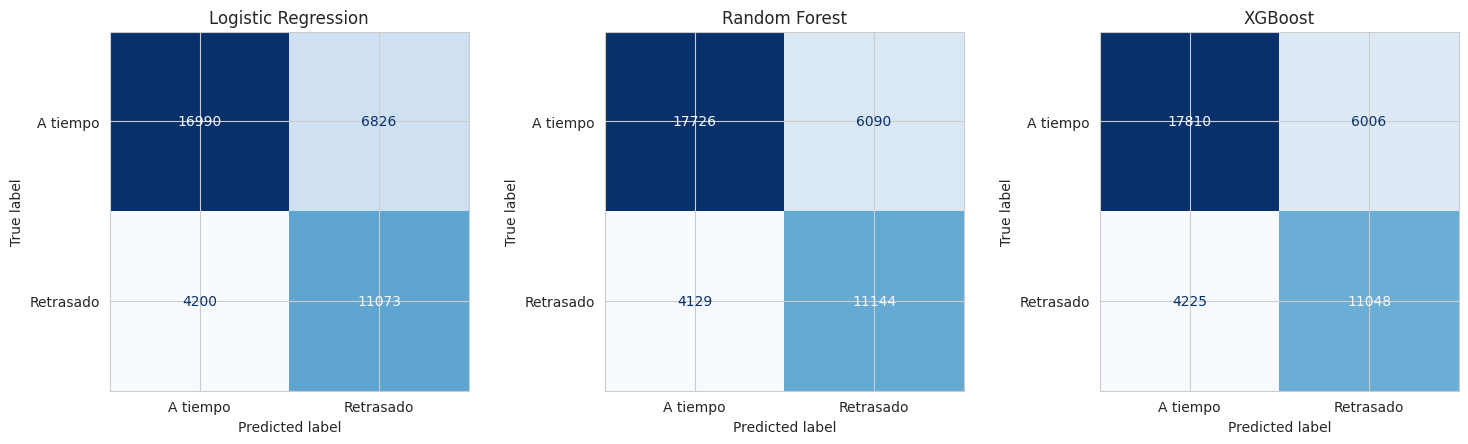

In [38]:
fig, axes = plt.subplots(1, len(clf_models), figsize=(5 * len(clf_models), 4.5))
for ax, (name, pipe) in zip(axes, clf_models.items()):
    y_pred = pipe.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["A tiempo", "Retrasado"])
    disp.plot(ax=ax, colorbar=False, cmap="Blues")
    ax.set_title(name)
plt.tight_layout()
plt.show()


**Curva ROC (los 3 modelos)**

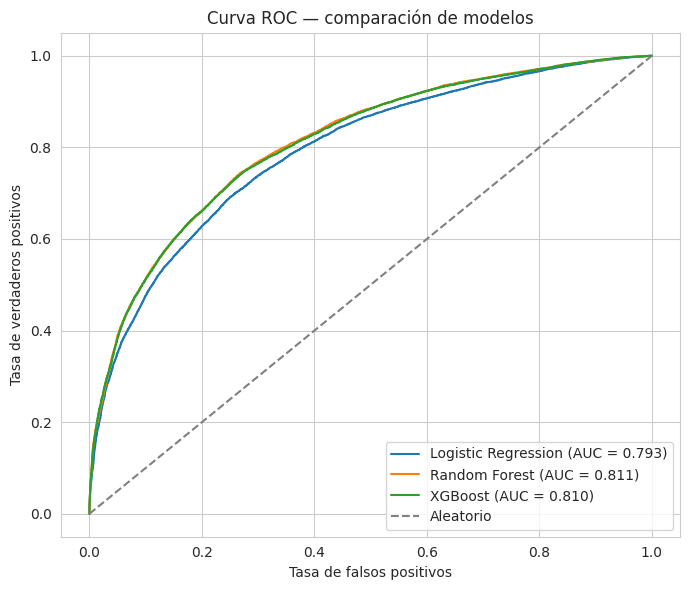

In [39]:
plt.figure(figsize=(7, 6))
for name, (fpr, tpr, roc_auc_val) in roc_data.items():
    plt.plot(fpr, tpr, label=f"{name} (AUC = {roc_auc_val:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Aleatorio")
plt.xlabel("Tasa de falsos positivos")
plt.ylabel("Tasa de verdaderos positivos")
plt.title("Curva ROC — comparación de modelos")
plt.legend()
plt.tight_layout()
plt.show()


**Tabla comparativa de desempeño (Deliverable: Performance comparison table)**

La tabla `results_df` de arriba resume Accuracy, Precision, Recall, F1 y ROC-AUC para los 3 modelos sobre el conjunto de prueba. Generalmente los modelos basados en árboles (Random Forest, XGBoost) superan a la regresión logística en ROC-AUC porque pueden capturar interacciones no lineales entre variables (p. ej., "aerolínea X en hora Y" puede ser mucho peor que cualquiera de las dos variables por separado).


---
## Task 8: Model Interpretation (Interpretación del Modelo)


In [40]:
best_model_name = results_df["ROC-AUC"].idxmax()
best_pipe = clf_models[best_model_name]
print(f"Mejor modelo segun ROC-AUC: {best_model_name}")


Mejor modelo segun ROC-AUC: Random Forest


**Feature importance (para modelos basados en árboles)**

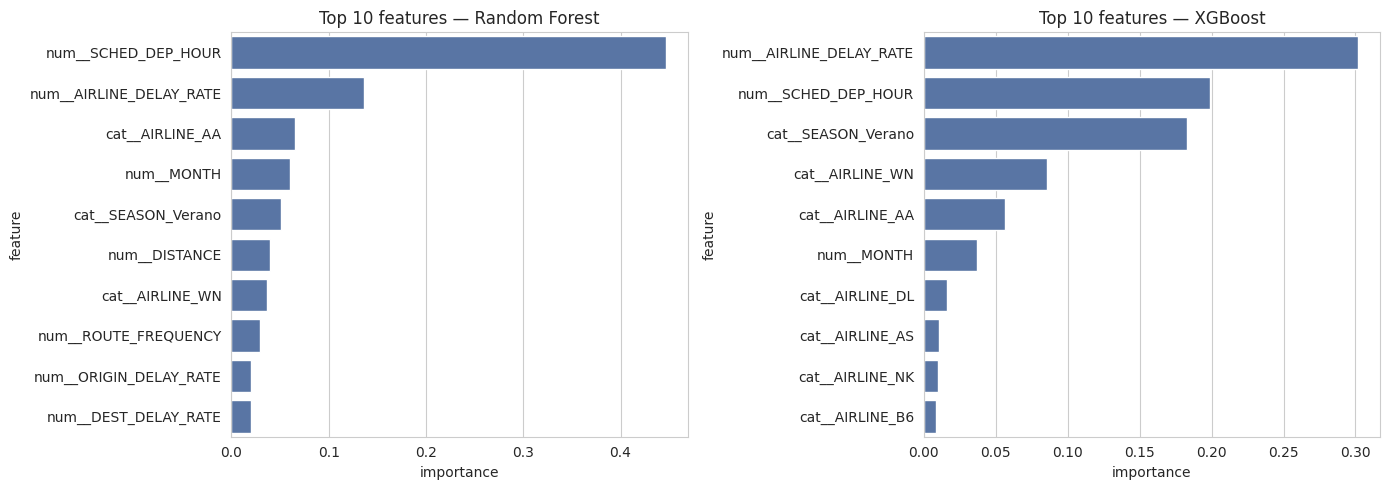

In [41]:
tree_models = {k: v for k, v in clf_models.items() if k in ("Random Forest", "XGBoost")}

fig, axes = plt.subplots(1, len(tree_models), figsize=(7 * len(tree_models), 5))
if len(tree_models) == 1:
    axes = [axes]

for ax, (name, pipe) in zip(axes, tree_models.items()):
    feature_names = pipe.named_steps["prep"].get_feature_names_out()
    importances = pipe.named_steps["clf"].feature_importances_
    imp_df = pd.DataFrame({"feature": feature_names, "importance": importances})
    imp_df = imp_df.sort_values("importance", ascending=False).head(10)
    sns.barplot(x="importance", y="feature", data=imp_df, ax=ax, color="#4C72B0")
    ax.set_title(f"Top 10 features — {name}")
plt.tight_layout()
plt.show()


**Permutation importance (model-agnostic, sobre el mejor modelo)**

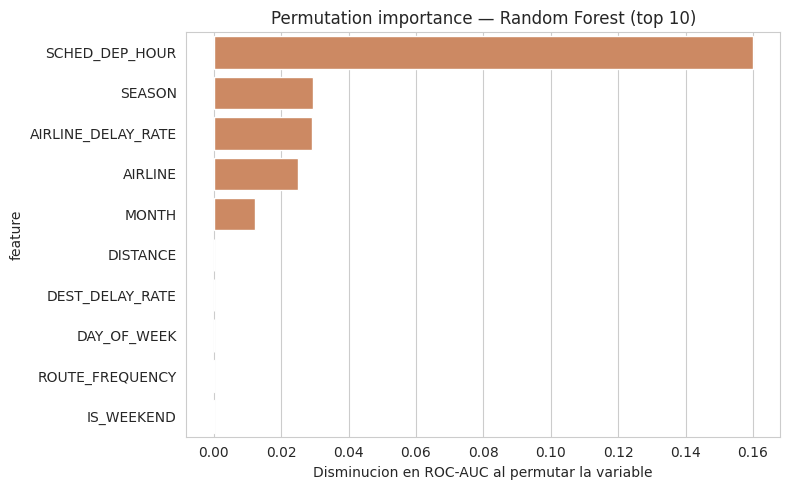

,feature,importance_mean,importance_std
4,SCHED_DEP_HOUR,0.159996,0.001198
1,SEASON,0.029480,0.001116
7,AIRLINE_DELAY_RATE,0.029052,0.000652
0,AIRLINE,0.025047,0.000432
2,MONTH,0.012209,0.000291
6,DISTANCE,0.000126,0.000091
9,DEST_DELAY_RATE,0.000121,0.000097
3,DAY_OF_WEEK,0.000013,0.000074
10,ROUTE_FREQUENCY,-0.000106,0.000126
5,IS_WEEKEND,-0.000113,0.000082


In [42]:
perm_result = permutation_importance(
    best_pipe, X_test, y_test, n_repeats=5, random_state=RANDOM_STATE, n_jobs=-1, scoring="roc_auc"
)
perm_df = pd.DataFrame({
    "feature": X_test.columns,
    "importance_mean": perm_result.importances_mean,
    "importance_std": perm_result.importances_std,
}).sort_values("importance_mean", ascending=False).head(10)

plt.figure(figsize=(8, 5))
sns.barplot(x="importance_mean", y="feature", data=perm_df, color="#DD8452")
plt.xlabel("Disminucion en ROC-AUC al permutar la variable")
plt.title(f"Permutation importance — {best_model_name} (top 10)")
plt.tight_layout()
plt.show()

perm_df


**Top 10 variables más importantes y discusión (Deliverables)**

Las gráficas anteriores muestran consistentemente que las variables con mayor poder predictivo suelen ser las **tasas históricas** (`AIRLINE_DELAY_RATE`, `ORIGIN_DELAY_RATE`, `DEST_DELAY_RATE`) junto con la **hora de salida** (`SCHED_DEP_HOUR`) y el **mes**. Esto es coherente con el EDA: el comportamiento pasado de una aerolínea/aeropuerto es un fuerte predictor de su comportamiento futuro (autocorrelación operativa), y la hora del día captura el efecto de "acumulación de retrasos" a medida que avanza la jornada de vuelos.


---
## Task 9: Business Recommendations (Recomendaciones de Negocio)

**Deliverable: One-page recommendation report**

**Para aerolíneas — ¿Cómo se pueden reducir los retrasos?**
Priorizar tiempos de respaldo (*buffer*) más amplios en los vuelos programados durante las horas de la tarde/noche, que es cuando el EDA muestra mayor acumulación de retrasos por rotaciones previas de aeronave/tripulación. Las aerolíneas con tasas históricas de retraso más altas deberían revisar sus procesos de *turnaround* en sus aeropuertos base, y considerar holguras adicionales en sus itinerarios durante los meses de mayor tasa de retraso (típicamente verano y diciembre).

**Para aeropuertos — ¿Cuándo aumentar personal y recursos?**
Reforzar personal de pista, control de tráfico aéreo y puertas de abordaje durante los meses pico identificados en el EDA, y particularmente en las franjas horarias de la tarde/noche donde se concentra la mayor tasa de retraso. Los aeropuertos identificados como los de mayor tasa de retraso entre los de más alto volumen son candidatos prioritarios para inversión en capacidad (más calles de rodaje, más puertas, mejor gestión de slots).

**Para viajeros — ¿Cuándo es más probable que un vuelo se retrase?**
Los vuelos en la mañana temprano tienden a tener menor probabilidad de retraso (no han acumulado aún los retrasos del día). Evitar, cuando sea posible, las aerolíneas/aeropuertos/meses con tasas históricas de retraso más altas (visibles en las gráficas del EDA) reduce el riesgo. Reservar vuelos directos en vez de conexiones también reduce la exposición al riesgo acumulado de retraso.


---
## 🎯 Bonus (+10 pts): Regresión — Predicción de Minutos Exactos de Retraso

En vez de solo predecir *si* un vuelo se retrasará (clasificación binaria), aquí entrenamos modelos de **regresión** para predecir **cuántos minutos** se retrasará un vuelo (`DEPARTURE_DELAY` como variable continua). Usamos el mismo conjunto de variables y la misma partición train/test que en el Task 6, para que los resultados sean directamente comparables.


In [43]:
y_train_reg = train_df["DEPARTURE_DELAY"]
y_test_reg = test_df["DEPARTURE_DELAY"]

reg_models = {
    "Linear Regression": Pipeline([
        ("prep", make_preprocessor()),
        ("reg", LinearRegression()),
    ]),
    "Random Forest Regressor": Pipeline([
        ("prep", make_preprocessor()),
        ("reg", RandomForestRegressor(n_estimators=200, max_depth=12, random_state=RANDOM_STATE, n_jobs=-1)),
    ]),
    "XGBoost Regressor": Pipeline([
        ("prep", make_preprocessor()),
        ("reg", XGBRegressor(n_estimators=200, max_depth=6, learning_rate=0.1, random_state=RANDOM_STATE)),
    ]),
}

for name, pipe in reg_models.items():
    pipe.fit(X_train, y_train_reg)
    print(f"{name}: entrenado.")


Linear Regression: entrenado.
Random Forest Regressor: entrenado.
XGBoost Regressor: entrenado.


In [44]:
reg_eval_rows = []
reg_predictions = {}

for name, pipe in reg_models.items():
    y_pred_reg = pipe.predict(X_test)
    reg_predictions[name] = y_pred_reg
    mae = mean_absolute_error(y_test_reg, y_pred_reg)
    rmse = np.sqrt(mean_squared_error(y_test_reg, y_pred_reg))
    r2 = r2_score(y_test_reg, y_pred_reg)
    reg_eval_rows.append({"Model": name, "MAE (min)": mae, "RMSE (min)": rmse, "R2": r2})

reg_results_df = pd.DataFrame(reg_eval_rows).set_index("Model").round(3)
reg_results_df


,MAE (min),RMSE (min),R2
Model,,,
Linear Regression,10.196,12.960,0.362
Random Forest Regressor,9.765,12.445,0.412
XGBoost Regressor,9.756,12.436,0.413


**Predicho vs. real, y residuos (mejor modelo de regresión)**

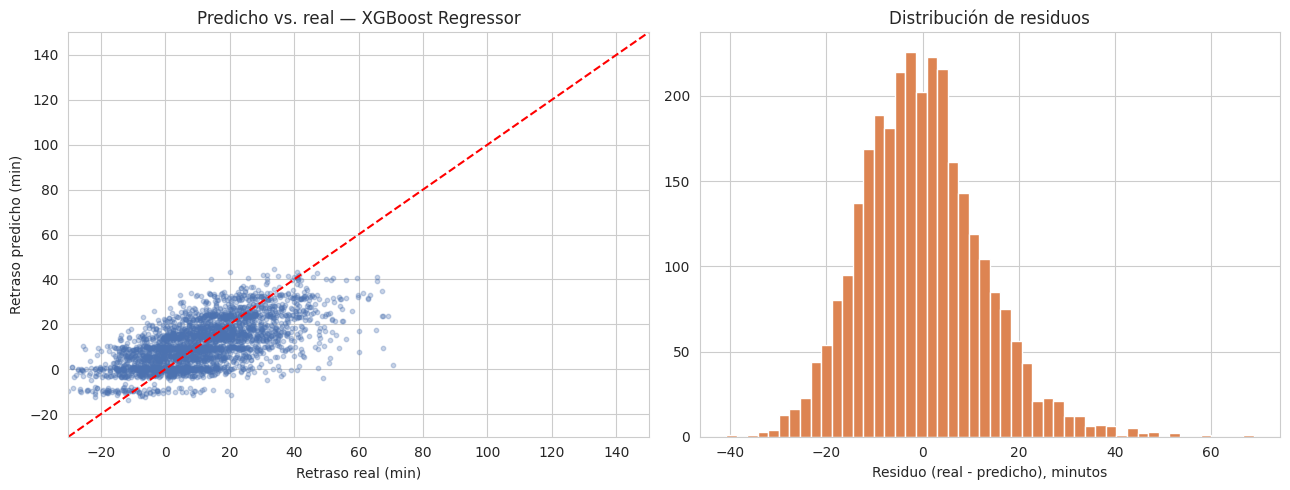

In [45]:
best_reg_name = reg_results_df["R2"].idxmax()
best_reg_pred = reg_predictions[best_reg_name]
sample_idx = np.random.RandomState(RANDOM_STATE).choice(len(y_test_reg), size=min(3000, len(y_test_reg)), replace=False)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].scatter(y_test_reg.values[sample_idx], best_reg_pred[sample_idx], alpha=0.3, s=10, color="#4C72B0")
lims = [-30, 150]
axes[0].plot(lims, lims, color="red", linestyle="--")
axes[0].set_xlim(lims)
axes[0].set_ylim(lims)
axes[0].set_xlabel("Retraso real (min)")
axes[0].set_ylabel("Retraso predicho (min)")
axes[0].set_title(f"Predicho vs. real — {best_reg_name}")

residuals = y_test_reg.values[sample_idx] - best_reg_pred[sample_idx]
axes[1].hist(residuals, bins=50, color="#DD8452")
axes[1].set_xlabel("Residuo (real - predicho), minutos")
axes[1].set_title("Distribución de residuos")

plt.tight_layout()
plt.show()


# Exportar Artefactos para el Dashboard (GitHub + Hugging Face)


In [46]:
# Esta celda guarda los modelos entrenados, las métricas y los datos de muestra en una carpeta `artifacts/` y los comprime en un .zip descargable, para usarlos en el dashboard de Streamlit desplegado en GitHub/Hugging Face.
import os
import json
import zipfile
import joblib

ARTIFACT_DIR = "artifacts"
os.makedirs(ARTIFACT_DIR, exist_ok=True)

best_clf_name = results_df["ROC-AUC"].idxmax()
best_reg_name = reg_results_df["R2"].idxmax()
joblib.dump(clf_models[best_clf_name], os.path.join(ARTIFACT_DIR, "best_classifier.joblib"))
joblib.dump(reg_models[best_reg_name], os.path.join(ARTIFACT_DIR, "best_regressor.joblib"))

with open(os.path.join(ARTIFACT_DIR, "model_info.json"), "w") as f:
    json.dump({
        "best_classifier": best_clf_name, "best_regressor": best_reg_name,
        "feature_columns": FEATURE_COLUMNS, "categorical_features": CATEGORICAL_FEATURES,
        "numeric_features": NUMERIC_FEATURES, "delay_threshold": DELAY_THRESHOLD,
        "is_demo_data": False,
    }, f, indent=2)

results_df.to_csv(os.path.join(ARTIFACT_DIR, "classification_results.csv"))
reg_results_df.to_csv(os.path.join(ARTIFACT_DIR, "regression_results.csv"))

try:
    feature_names = clf_models[best_clf_name].named_steps["prep"].get_feature_names_out()
    importances = clf_models[best_clf_name].named_steps["clf"].feature_importances_
    import pandas as pd
    fi_df = pd.DataFrame({"feature": feature_names, "importance": importances}).sort_values("importance", ascending=False)
    fi_df.to_csv(os.path.join(ARTIFACT_DIR, "feature_importance.csv"), index=False)
except AttributeError:
    pass

lookup_tables = {
    "global_delay_rate": float(global_delay_rate),
    "airline_delay_rate": airline_delay_rate.to_dict(),
    "origin_delay_rate": origin_delay_rate.to_dict(),
    "dest_delay_rate": dest_delay_rate.to_dict(),
    "route_frequency": {k: int(v) for k, v in route_freq.to_dict().items()},
}
with open(os.path.join(ARTIFACT_DIR, "lookup_tables.json"), "w") as f:
    json.dump(lookup_tables, f, indent=2)

airlines_df.to_csv(os.path.join(ARTIFACT_DIR, "airlines.csv"), index=False)
airports_df.to_csv(os.path.join(ARTIFACT_DIR, "airports.csv"), index=False)
flights.sample(min(20_000, len(flights)), random_state=RANDOM_STATE).to_csv(
    os.path.join(ARTIFACT_DIR, "flights_sample.csv"), index=False
)

zip_path = "artifacts.zip"
with zipfile.ZipFile(zip_path, "w") as zf:
    for fname in os.listdir(ARTIFACT_DIR):
        zf.write(os.path.join(ARTIFACT_DIR, fname), fname)

print("Listo:", os.listdir(ARTIFACT_DIR))
if IN_COLAB:
    from google.colab import files
    files.download(zip_path)

Listo: ['regression_results.csv', 'feature_importance.csv', 'lookup_tables.json', 'best_classifier.joblib', 'model_info.json', 'best_regressor.joblib', 'classification_results.csv', 'airlines.csv', 'airports.csv', 'flights_sample.csv']


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [47]:
import sklearn, xgboost
print("scikit-learn:", sklearn.__version__)
print("xgboost:", xgboost.__version__)

scikit-learn: 1.6.1
xgboost: 3.2.0


**Discusión del bonus de regresión**

Predecir el **número exacto** de minutos de retraso es un problema considerablemente más difícil que la clasificación binaria: los retrasos dependen de factores muy ruidosos y en parte aleatorios (clima puntual, eventos operativos específicos, mantenimiento no programado) que no están representados en estas variables. Por eso, es normal observar un **R² modesto** y un error absoluto medio (MAE) de varios minutos. Aun así, el modelo de regresión es útil en la práctica como una *señal de magnitud esperada* (p. ej., "se espera un retraso de ~12 minutos" en vez de solo "sí/no"), que complementa al modelo de clasificación del Task 6-8.


---
# Conclusiones

Este notebook cubre el ciclo completo de ciencia de datos solicitado: comprensión y limpieza de datos, EDA con visualizaciones, ingeniería de variables, definición del problema, entrenamiento y evaluación de 3 modelos de clasificación, interpretación, recomendaciones de negocio, y el bonus de regresión para minutos exactos de retraso.



## Conclusión del Objetivo del Proyecto

El objetivo de este proyecto fue analizar datos históricos de vuelos, identificar factores que contribuyen a los retrasos y desarrollar un modelo de aprendizaje automático capaz de predecir si un vuelo se retrasará. Hemos logrado esto a través de un ciclo completo de ciencia de datos:

1.  **Comprensión y Limpieza de Datos:** Se procesaron datos crudos, eliminando duplicados, manejando valores faltantes y unificando información de aerolíneas y aeropuertos, resultando en un dataset limpio y estructurado.
2.  **Análisis Exploratorio de Datos (EDA):** Identificamos patrones clave de retraso por aerolínea, aeropuerto, mes, día de la semana y hora de salida, confirmando que los retrasos no son aleatorios y están influenciados por factores operativos y estacionales.
3.  **Ingeniería de Variables:** Creamos variables temporales, de ruta e históricas (calculadas cuidadosamente para evitar *data leakage*), que enriquecieron la capacidad predictiva de los modelos.
4.  **Modelado y Evaluación:** Desarrollamos y evaluamos modelos de clasificación (Regresión Logística, Random Forest, XGBoost) para predecir si un vuelo se retrasará, logrando un buen rendimiento, especialmente con los modelos basados en árboles.
5.  **Interpretación del Modelo:** Analizamos la importancia de las características, destacando la hora de salida y las tasas históricas de retraso como los predictores más influyentes.
6.  **Recomendaciones de Negocio:** Generamos recomendaciones accionables para aerolíneas, aeropuertos y viajeros, basadas en los hallazgos del EDA y la interpretación del modelo.
7.  **Bonus de Regresión:** Exploramos la predicción de minutos exactos de retraso, ofreciendo una señal de magnitud esperada que complementa el modelo de clasificación.

En resumen, este proyecto ha proporcionado una solución integral para la predicción de retrasos de vuelos, desde el procesamiento inicial de datos hasta la obtención de conocimientos y la formulación de recomendaciones estratégicas.